# Phase 00–02 EDA — every dataset downloaded so far

This notebook inventories **everything currently on disk** for EuroGrid-Climate-Dynamics:

| source | product | variables | cadence | extent | windows cached |
|---|---|---|---|---|---|
| ERA5 (ARCO, Google Cloud) | reanalysis, 0.25° | `u100`, `v100`, `ws100`, `sp` (hourly); `z500` (6 h stride) | hourly | Euro-Atlantic box 30–75°N, 40°W–40°E | Jan 2023 (smoke), Nov–Dec 2024 (dark-lull validation) |
| SMARD (Bundesnetzagentur) | observed generation + installed capacity, Germany | wind onshore, wind offshore, solar — MW | hourly | 4 TSO zones: 50Hertz, TenneT, Amprion, TransnetBW | Jan 2023, Nov–Dec 2024 |

Not yet downloaded: **EERIE IFS-FESOM2** (the climate model — Phase 06, still gated).

How to read this: each section shows *what the data actually is* (dims, units, coordinates),
then a spatial picture, then distributions and gaps — so you can sanity-check it like a scientist
before anything is computed from it.


In [1]:
import glob
import os
import pathlib
from datetime import datetime

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
import yaml

from eurogrid.data.smard import SmardClient, capacity_factor
from eurogrid.models.transfer import FLEET_BOXES

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)

os.chdir(ROOT)

cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))


WINDOWS = {"2023-01": ("2023-01-01", "2023-02-01"), "2024-11..12": ("2024-11-01", "2025-01-01")}

era5 = {
    w: xr.open_zarr(
        glob.glob(
            f"data/era5/era5_{datetime.fromisoformat(s):%Y%m%dT%H}"
            f"_{datetime.fromisoformat(e):%Y%m%dT%H}_*.zarr"
        )[0],
        consolidated=True,
    )
    for w, (s, e) in WINDOWS.items()
}
era5.keys()

dict_keys(['2023-01', '2024-11..12'])

## 1. ERA5 — atmospheric reanalysis

**What it is:** ECMWF's hourly reanalysis — the closest thing to 'truth' for the atmosphere.
We use Google's ARCO mirror (`arco-era5`), read anonymously from a public Zarr store.

**What we downloaded and why:**
- `u100`, `v100` — eastward/northward wind at **100 m** (turbine hub-height proxy; ERA5 has a real 100 m diagnostic, the climate model doesn't — that's the asymmetry the project is built around).
- `ws100 = hypot(u100, v100)` — wind speed, computed by our loader.
- `sp` — surface pressure. Needed to flag where a climate-model pressure level would dip below ground.
- `z500` — 500 hPa geopotential **height**, 6-hourly. The input to the Tibaldi–Molteni blocking index.

**Deliberate asymmetries:** `z500` is on its own `time_z500` axis at a 6 h stride — each hourly Z500
field costs a full 37-level global chunk from the store, and the blocking index is a *daily* diagnostic,
so 6-hourly is enough. Longitude is wrapped to [−180°, 180°), latitude strictly descending — the
canonical contract every loader must satisfy.


In [2]:
# Dataset inventory: dims, sizes, variables, units

rows = []

for w, ds in era5.items():
    for v in ds.data_vars:
        da = ds[v]

        rows.append(
            {
                "window": w,
                "variable": v,
                "dims": str(da.dims),
                "shape": tuple(da.shape),
                "units": da.attrs.get("units"),
                "time_range": f"{da[da.dims[0]].values[0]} -> {da[da.dims[0]].values[-1]}"[:44],
            }
        )

pl.DataFrame(rows)

window,variable,dims,shape,units,time_range
str,str,str,list[i64],str,str
"""2023-01""","""sp""","""('time', 'lat', 'lon')""","[744, 181, 321]","""Pa""","""2023-01-01T00:00:00.000000000 …"
"""2023-01""","""u100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00.000000000 …"
"""2023-01""","""v100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00.000000000 …"
"""2023-01""","""ws100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00.000000000 …"
"""2023-01""","""z500""","""('time_z500', 'lat', 'lon')""","[124, 181, 321]","""m""","""2023-01-01T00:00:00.000000000 …"
"""2024-11..12""","""sp""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""Pa""","""2024-11-01T00:00:00.000000000 …"
"""2024-11..12""","""u100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00.000000000 …"
"""2024-11..12""","""v100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00.000000000 …"
"""2024-11..12""","""ws100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00.000000000 …"


**The domain.** Everything is cropped to the Euro-Atlantic analysis box (30–75°N, 40°W–40°E),
regridded-free at the store's native 0.25°. Coloured field: January-mean 100 m wind speed. 
Rectangles: the two static *fleet-proxy* boxes used by the Phase 03 transfer function — onshore Germany
(red) and the German North-Sea Bight for offshore (blue). SMARD data covers Germany only, which is why
the fleet boxes sit inside the larger box: the large domain is for blocking/circulation, the small ones
for generation.


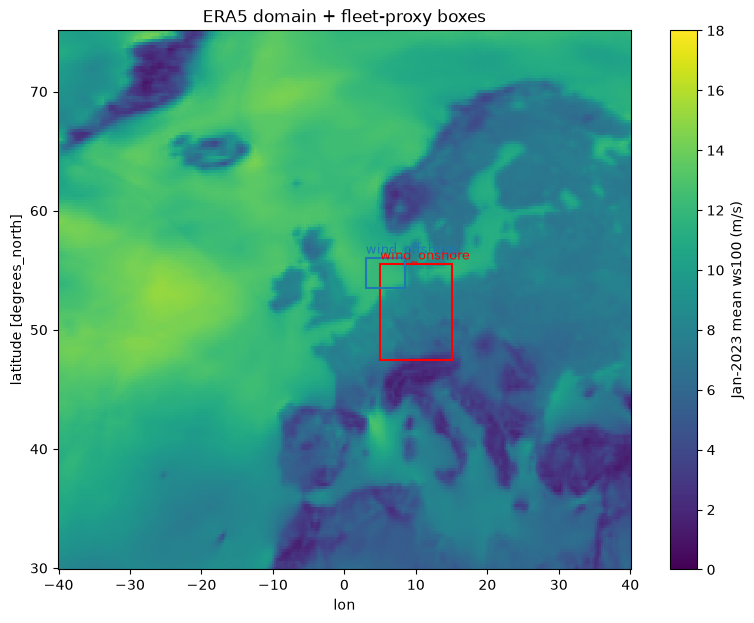

In [3]:
ds = era5["2023-01"]

fig, ax = plt.subplots(figsize=(10, 7))

ds.ws100.mean("time").plot(
    ax=ax, cmap="viridis", vmin=0, vmax=18, cbar_kwargs={"label": "Jan-2023 mean ws100 (m/s)"}
)

for (name, (la0, la1, lo0, lo1)), col in zip(FLEET_BOXES.items(), ["red", "tab:blue"], strict=True):
    ax.add_patch(mpatches.Rectangle((lo0, la0), lo1 - lo0, la1 - la0, fill=False, ec=col, lw=1.5))

    ax.text(lo0, la1 + 0.4, name, color=col, fontsize=9)

ax.set_title("ERA5 domain + fleet-proxy boxes")

ax.set_aspect(1 / 0.6)

plt.show()

**Distributions.** What the wind actually looks like: domain-mean time series and per-cell
distributions for Jan 2023. Expected sanity checks: North-Sea cells sit ~10–15 m/s, land cells
much lower; `sp` near 101 kPa; `z500` between ~4900 and ~5900 m.


In [4]:
stats = []

for w, d in era5.items():
    for v in ["ws100", "sp"]:
        a = d[v].values.ravel()

        stats.append(
            {
                "window": w,
                "var": v,
                "mean": a.mean(),
                "std": a.std(),
                "p01": np.percentile(a, 1),
                "p50": np.percentile(a, 50),
                "p99": np.percentile(a, 99),
                "nan_frac": np.isnan(a).mean(),
            }
        )

pl.DataFrame(stats)

window,var,mean,std,p01,p50,p99,nan_frac
str,str,f64,f64,f64,f64,f64,f64
"""2023-01""","""ws100""",9.198788,5.321138,0.785209,8.473738,23.304243,0.0
"""2023-01""","""sp""",98865.632812,5799.618652,68557.765625,100335.890625,103750.960938,0.0
"""2024-11..12""","""ws100""",8.886057,5.28858,0.751936,8.081741,23.301638,0.0
"""2024-11..12""","""sp""",99070.234375,5708.672363,69171.617188,100735.8125,103711.234375,0.0


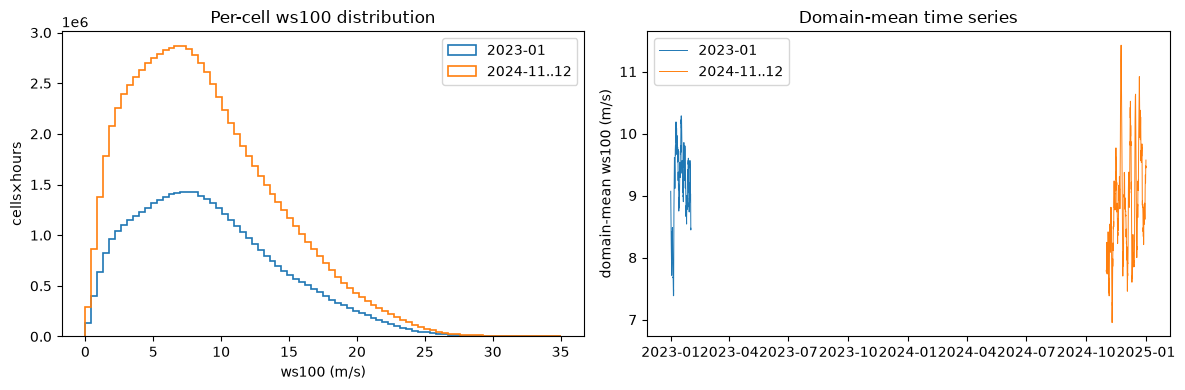

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for w, d in era5.items():
    axes[0].hist(d.ws100.values.ravel(), bins=80, range=(0, 35), histtype="step", lw=1.2, label=w)

    axes[1].plot(d.time.values, d.ws100.mean(("lat", "lon")).values, lw=0.7, label=w)

axes[0].set(xlabel="ws100 (m/s)", ylabel="cells×hours", title="Per-cell ws100 distribution")
axes[0].legend()

axes[1].set(ylabel="domain-mean ws100 (m/s)", title="Domain-mean time series")
axes[1].legend()

fig.tight_layout()
plt.show()

**Circulation.** Mean Z500 map (the blocking-index input): ridge/trough structure should be visible —
this is the field that has to look right for TM1990 to mean anything. Contour interval 60 m.


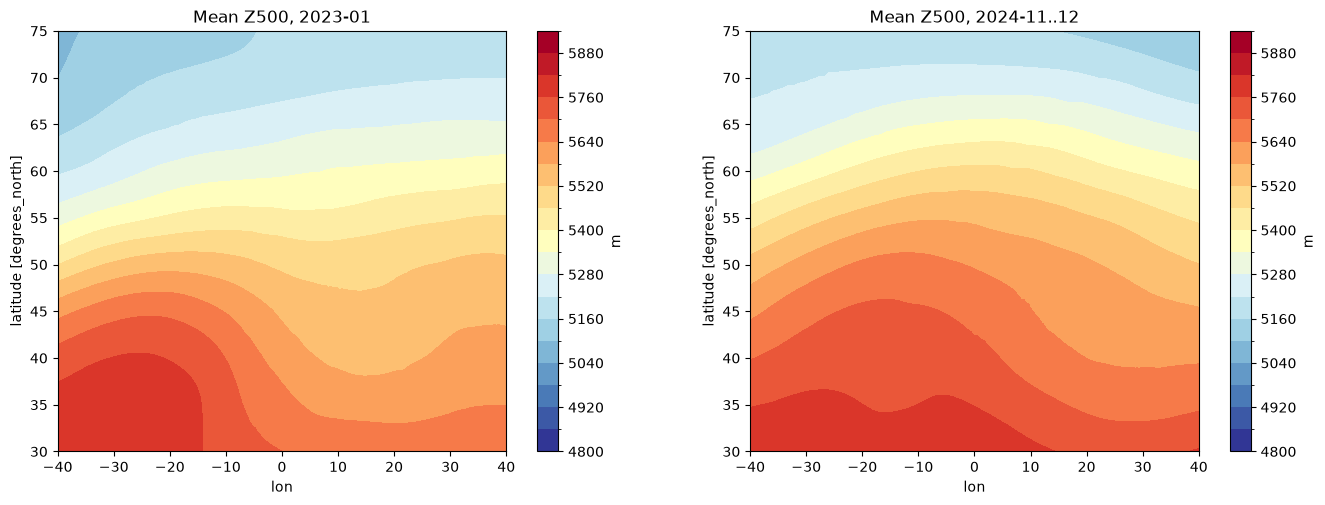

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w in zip(axes, era5, strict=True):
    z = era5[w].z500.mean("time_z500")

    c = z.plot.contourf(
        ax=ax, levels=range(4800, 6000, 60), cmap="RdYlBu_r", add_colorbar=True, cbar_kwargs={"label": "m"}
    )

    ax.set_title(f"Mean Z500, {w}")
    ax.set_aspect(1 / 0.6)

fig.tight_layout()
plt.show()

## 2. SMARD — observed German generation

**What it is:** the Bundesnetzagentur's market-data platform — actual metered feed-in per
transmission-system-operator zone, the ground truth the transfer function is validated against.

**What we downloaded:** hourly generation **and installed capacity** for wind onshore, wind offshore,
solar, in all four TSO zones. Capacity matters because SMARD reports *generation*, and what we need
for comparison is the *capacity factor* — generation divided by the capacity installed at that moment
(the German fleet grew substantially over the period, so a constant denominator would be wrong).

**Provenance caveat:** generation filter IDs are public; the installed-capacity IDs (186/187/188) were
inferred by matching Germany-wide yearly totals to known capacities (2015 and 2024) — check the
capacity series below before trusting them.


In [7]:
smard = SmardClient(cache_dir=cfg["smard"]["cache_dir"])

frames = {}

for w, (s, e) in WINDOWS.items():
    s, e = datetime.fromisoformat(s), datetime.fromisoformat(e)

    frames[w] = {
        "gen": smard.load_generation(s, e),
        "cap": smard.load_installed_capacity(s, e),
    }


inv = []

for w, f in frames.items():
    for kind, df in f.items():
        g = df.group_by("zone", "variable").agg(
            n=pl.len(),
            nulls=pl.col("value_mw").null_count(),
            mean_mw=pl.col("value_mw").mean(),
            max_mw=pl.col("value_mw").max(),
        )

        inv += [dict(window=w, kind=kind, **r) for r in g.to_dicts()]

pl.DataFrame(inv).sort("window", "kind", "zone", "variable")

window,kind,zone,variable,n,nulls,mean_mw,max_mw
str,str,str,str,i64,i64,f64,f64
"""2023-01""","""cap""","""50Hertz""","""solar""",744,0,16250.0,16250.0
"""2023-01""","""cap""","""50Hertz""","""wind_offshore""",744,0,1093.0,1093.0
"""2023-01""","""cap""","""50Hertz""","""wind_onshore""",744,0,20756.0,20756.0
"""2023-01""","""cap""","""Amprion""","""solar""",744,0,14475.0,14475.0
"""2023-01""","""cap""","""Amprion""","""wind_offshore""",744,0,0.0,0.0
…,…,…,…,…,…,…,…
"""2024-11..12""","""gen""","""TenneT""","""wind_offshore""",1464,0,2505.301742,6066.5
"""2024-11..12""","""gen""","""TenneT""","""wind_onshore""",1464,0,7030.605874,19195.0
"""2024-11..12""","""gen""","""TransnetBW""","""solar""",1464,0,323.635587,3208.5


**Installed capacity** — the denominator. Step-wise (SMARD updates it when plants connect).
Offshore exists only in 50Hertz and TenneT; for Amprion/TransnetBW it is a real zero,
not missing data. Solar capacity roughly doubled between our windows' era — visible here.
If a line looks absurd vs known German totals (~60 GW onshore, ~9 GW offshore, ~90 GW PV by 2024),
the inferred capacity filter IDs are wrong — this is the check for that.


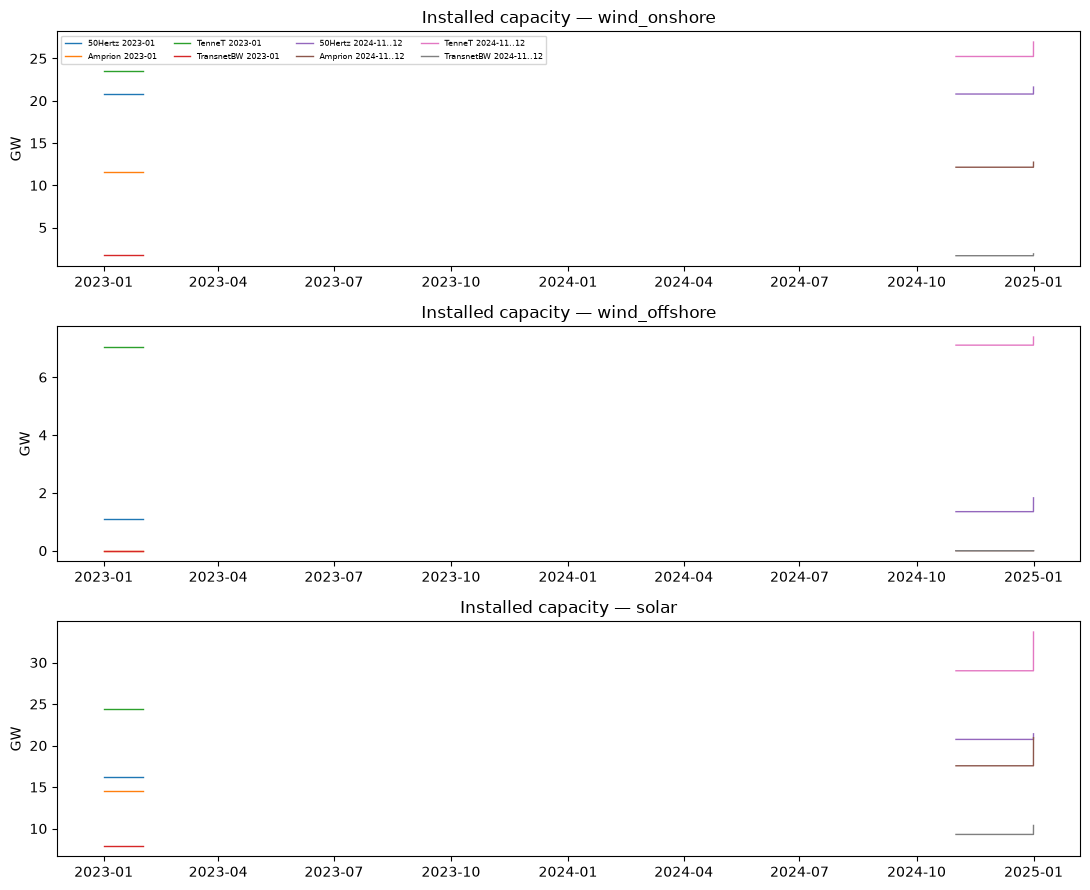

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)

for ax, var in zip(axes, ["wind_onshore", "wind_offshore", "solar"], strict=True):
    for w, f in frames.items():
        d = f["cap"].filter(pl.col("variable") == var).to_pandas()

        for z, g in d.groupby("zone"):
            ax.plot(g.time, g.value_mw / 1000, lw=1.0, label=f"{z} {w}" if var == "wind_onshore" else None)

    ax.set(ylabel="GW", title=f"Installed capacity — {var}")

axes[0].legend(fontsize=6, ncol=4)

fig.tight_layout()
plt.show()

**Generation and capacity factors.** Left: mean hourly MW by zone in each window — winter wind
dominates, solar is ~2% of capacity. Right: CF distributions — the shape of the resource we are
trying to model. Watch Nov–Dec 2024: visibly lower CF — those months contain the dark-lull events
this project studies.


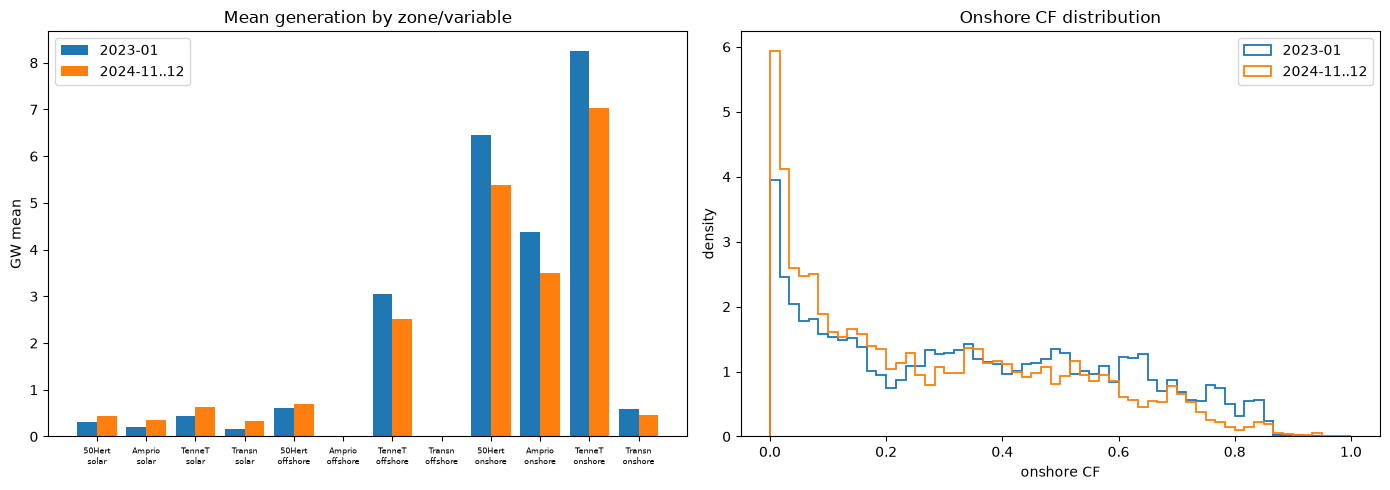

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cf_all = {}

for w, f in frames.items():
    cf_all[w] = capacity_factor(f["gen"], f["cap"])

    m = f["gen"].group_by("variable", "zone").agg(pl.col("value_mw").mean()).sort("variable", "zone")

    x = np.arange(m.height)

    axes[0].bar(x + (0.4 if w == "2024-11..12" else 0), m["value_mw"] / 1000, width=0.4, label=w)

    if w == "2023-01":
        axes[0].set_xticks(
            x + 0.2,
            [f"{z[:6]}\n{v.replace('wind_', '')}" for z, v in zip(m["zone"], m["variable"], strict=True)],
            fontsize=6,
        )

axes[0].set(ylabel="GW mean", title="Mean generation by zone/variable")
axes[0].legend()

for w, cf in cf_all.items():
    d = cf.filter(pl.col("variable") == "wind_onshore")["capacity_factor"].drop_nans()

    axes[1].hist(d.to_numpy(), bins=60, range=(0, 1), histtype="step", lw=1.3, density=True, label=w)

axes[1].set(xlabel="onshore CF", ylabel="density", title="Onshore CF distribution")
axes[1].legend()

fig.tight_layout()
plt.show()

**Gaps and quirks worth knowing:**
- SMARD has occasional `null` hours (visible in the inventory table's `nulls` column) — real gaps in the feed, kept as null not zero.
- Generation is MWh/interval; at hourly cadence that equals mean MW. Quarter-hourly is available but not downloaded.
- Solar has **no transfer function** in this project (no radiation variable downloaded) — it stays observed-only.



## 3. Coverage summary — what exists vs. what is planned

| | downloaded | planned (later phases) |
|---|---|---|
| ERA5 | ws100/u100/v100/sp hourly + z500 6h, Jan 2023 + Nov–Dec 2024, full domain | extend windows as needed for 30-yr blocking climatology |
| SMARD | hourly gen + capacity, 4 zones, Jan 2023 + Nov–Dec 2024 | quarter-hourly if ramp analysis needs it |
| EERIE | *nothing yet* | 3-D u/v/z pressure levels (6h), 2-D sp/gusts; hist-1950 + ssp245, Phase 06 gated on ERA5 pipeline |
| MaStR | *nothing* | turbine locations for capacity-weighted aggregation (biggest known transfer bias) |

**Reading order for the science:** ERA5 + SMARD are the calibration pair (Phases 03–05).
EERIE only enters after the same diagnostics reproduce ERA5's known answers — that is the
evaluative logic of the whole project.
